In [69]:
import os 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet

from CityScapes.datasets import CityScapesMultiResolutionDataset
from DCGAN.loss_functions import GradientPenaltyLoss, EntropyLoss, DriftLoss, WeightedMSELoss, TotalVariationLoss

device ="cuda" if torch.cuda.is_available() else "cpu"
scale_for_display = lambda x: x.mul(0.5).add(0.5)

In [70]:

encoder_channels = [512,256,128,64,32,32,16]

seg_gen_cut_connections = 3

batch_size = 8
lr = 1.0e-5

In [71]:

msg_dataset = CityScapesMultiResolutionDataset()
train_loader = DataLoader(msg_dataset, batch_size=batch_size, shuffle=True)

regular_unet = UNet(channels=encoder_channels,
                 out_channels=3,
                 cut_connections=seg_gen_cut_connections).to(device)

optimizer = optim.Adam(regular_unet.parameters(), lr=lr)

Dataset initialized with 19998 samples. Labels enabled: False


In [72]:
reconstruction_loss_fn  = nn.MSELoss()


In [73]:
# pretrain the rec_regular_unet to be good all over the place

epochs =2


for epoch in range(0, epochs):
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    for data,_ in loop:
        
        optimizer.zero_grad()

        full_img = data[-1].to(device)
    
        reconstructions= regular_unet(full_img)

        recon_loss = reconstruction_loss_fn(reconstructions, full_img)
        recon_loss.backward()
        optimizer.step()

        loop.set_postfix(
            recon_loss=recon_loss.item(),
         
        )
        



Epoch 1/2: 100%|██████████| 2500/2500 [01:38<00:00, 25.30it/s, recon_loss=0.0238]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05486211..1.2483518].


-0.3357028365135193 -0.32790225744247437 -0.007800601422786713


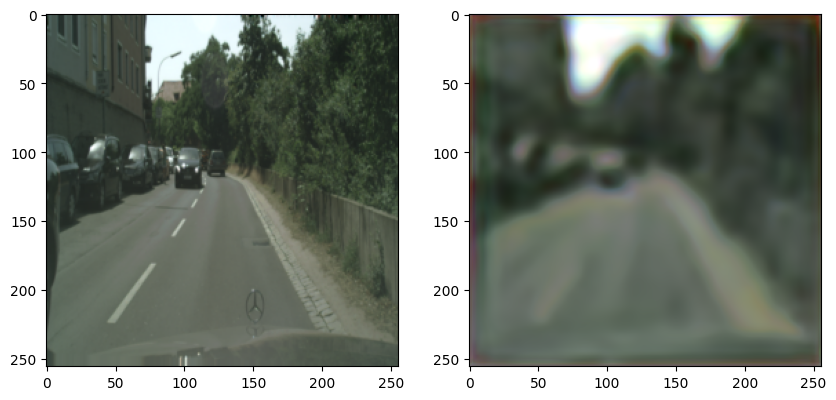

In [84]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    y = regular_unet(x)

fig,ax = plt.subplots(1,2,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y)
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())
print(x.mean().item(),y.mean().item(),(x-y).mean().item())